Install SAM2 from [SAM2](https://github.com/facebookresearch/sam2.git)

In [180]:
import os
os.getcwd()

'c:\\Users\\User\\ml_models\\sam2'

### Convert labels to binary mask

In [182]:
import json
import os
import numpy as np
import cv2

# Map your LabelMe labels to a category. Add any variants you used.
PAVEMENT_LABELS = {
    "concrete_sidewalk": "concrete",
    "brick_sidewalk":    "brick",
    # add others here if your naming differs
}

# Pixel values for the multi-class mask
CLASS_VALUES = {"background": 0, "concrete": 1, "brick": 2}


def labelme_to_masks(json_path, mode="binary"):
    """
    Convert one LabelMe JSON to a mask.
    mode="binary"     -> 255 = any pavement, 0 = background
    mode="multiclass" -> 0=bg, 1=concrete, 2=brick
    Reads image size directly from the JSON (imageHeight / imageWidth).
    """
    with open(json_path) as f:
        data = json.load(f)

    h = data["imageHeight"]
    w = data["imageWidth"]
    mask = np.zeros((h, w), dtype=np.uint8)

    for shape in data["shapes"]:
        if shape["shape_type"] != "polygon":
            continue
        label = shape["label"].strip().lower()
        if label not in PAVEMENT_LABELS:
            continue

        category = PAVEMENT_LABELS[label]
        pts = np.array(shape["points"], dtype=np.float32).round().astype(np.int32)

        if mode == "binary":
            cv2.fillPoly(mask, [pts], 255)
        else:  # multiclass
            cv2.fillPoly(mask, [pts], CLASS_VALUES[category])

    return mask


def batch_convert(folder, mode="binary"):
    """Convert every *.json in a folder into a *_mask.png next to it."""
    count = 0
    for fn in os.listdir(folder):
        if not fn.endswith(".json"):
            continue
        json_path = os.path.join(folder, fn)
        mask = labelme_to_masks(json_path, mode=mode)
        out_path = os.path.join(folder, fn.replace(".json", "_mask.png"))
        cv2.imwrite(out_path, mask)
        count += 1
        # quick sanity report
        coverage = (mask > 0).mean() * 100
        print(f"{fn} -> {out_path}  (pavement covers {coverage:.1f}% of image)")
    print(f"\nDone. Converted {count} files.")


# --- Run it ---
# batch_convert("sidewalk", mode="binary")
# batch_convert("data/eval/images", mode="binary")  # for your eval set

### Verifying masks

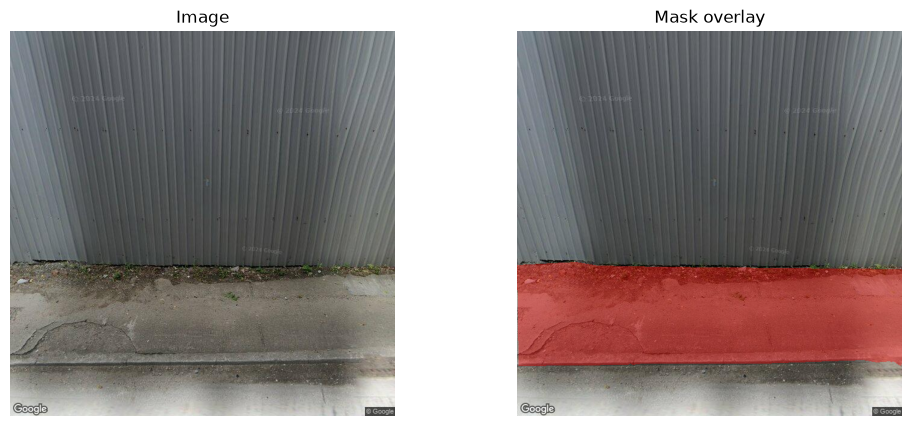

In [ ]:
import matplotlib.pyplot as plt

def check(img_path, json_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = labelme_to_masks(json_path, mode="binary")
    # resize mask if the loaded image was scaled differently (shouldn't be here)
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]
    blend = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(img);   ax[0].set_title("Image"); ax[0].axis("off")
    ax[1].imshow(blend); ax[1].set_title("Mask overlay"); ax[1].axis("off")
    # plt.tight_layout()
    # plt.savefig("sidewalk/check_overlay.png", dpi=600, bbox_inches="tight")
    plt.show()

check("sidewalk/support/concrete/22.50302958565_114.0861339521216_left.png", "sidewalk/annotations/22.50302958565_114.0861339521216_left.json")

### Building a few-shot pavement segmentation pipeline

discovered: {'concrete': 30}
  concrete: 30 prototype(s) from 30 sample(s)


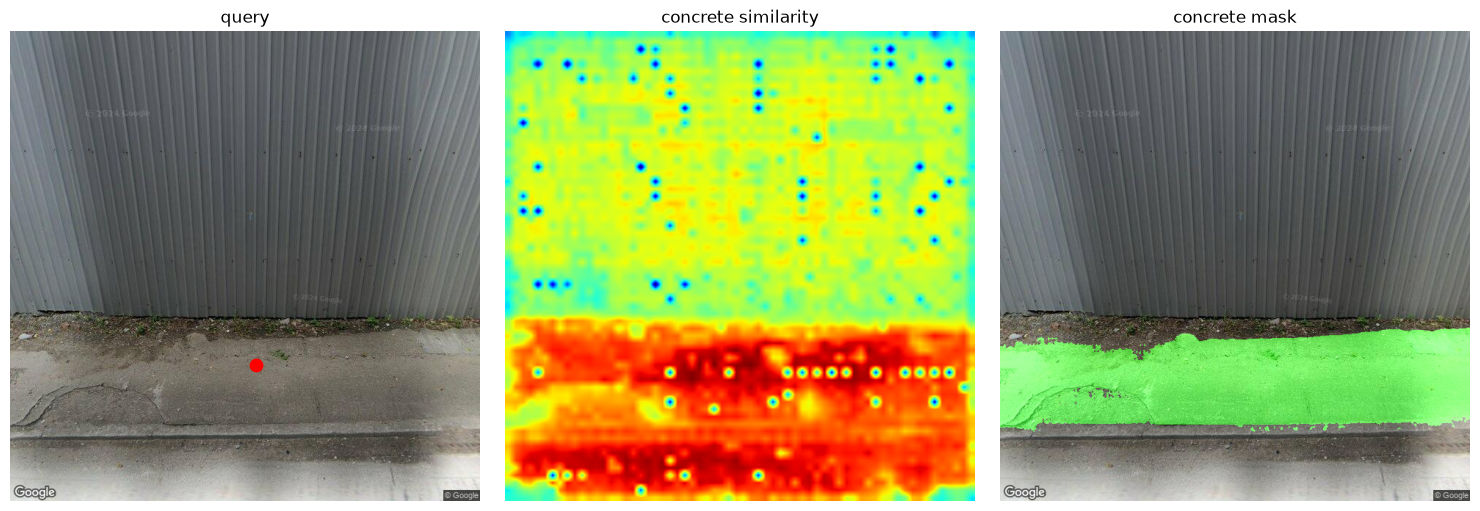

concrete: 74371 px (18.2% of image)


In [ ]:
# imports
import os, glob
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from scipy.ndimage import maximum_filter

from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# SAM2 imports
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- SAM2 (boxes -> masks) ---
# Config + checkpoint must match. Download checkpoints from the sam2 repo.
SAM2_CFG  = "configs/sam2.1/sam2.1_hiera_l.yaml"
SAM2_CKPT = "checkpoints/sam2.1_hiera_large.pt"
sam2_model = build_sam2(SAM2_CFG, SAM2_CKPT, device=device)
sam_predictor = SAM2ImagePredictor(sam2_model)

# ---------------------------------------------------------------------------
# I/O helpers
# ---------------------------------------------------------------------------
def load_image(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)        # RGB HWC uint8

def load_mask(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(path)
    return (m > 127).astype(np.uint8)                  # {0,1}

# ---------------------------------------------------------------------------
# Support discovery  ->  pass the PARENT dir; each subfolder = one class
#   sidewalk/support/
#   └── concrete/
#       ├── 22.50..._left.png
#       └── 22.50..._left_mask.png
# ---------------------------------------------------------------------------
def discover_support(support_dir, exts=(".jpg", ".jpeg", ".png")):
    support_data = {}
    for class_dir in sorted(glob.glob(os.path.join(support_dir, "*"))):
        if not os.path.isdir(class_dir):
            continue
        ptype = os.path.basename(class_dir)            # folder name = class
        for img_path in sorted(glob.glob(os.path.join(class_dir, "*"))):
            low = img_path.lower()
            if low.endswith("_mask.png"):
                continue
            if not low.endswith(exts):
                continue
            mask_path = os.path.splitext(img_path)[0] + "_mask.png"
            if not os.path.exists(mask_path):
                print(f"  [skip] no mask for {os.path.basename(img_path)}")
                continue
            support_data.setdefault(ptype, []).append((img_path, mask_path))
    return support_data

# ---------------------------------------------------------------------------
# Prototype building
# ---------------------------------------------------------------------------
def get_sam_features(image_np):
    sam_predictor.set_image(image_np)                  # RGB HWC uint8
    return sam_predictor._features["image_embed"].squeeze(0)   # (256, 64, 64)

def build_prototype(support_img, support_mask):
    feats = get_sam_features(support_img)
    C, fh, fw = feats.shape
    mask = cv2.resize(support_mask, (fw, fh), interpolation=cv2.INTER_NEAREST)
    mask_t = torch.tensor(mask, device=feats.device).bool().reshape(-1)
    if mask_t.sum() == 0:
        return None
    flat = feats.reshape(C, -1).T[mask_t]
    return F.normalize(flat.mean(0), dim=0)

# ---------------------------------------------------------------------------
# Build the bank  (ONE path, ONE loop)
# ---------------------------------------------------------------------------
support_data = discover_support("sidewalk/support")    # <-- parent dir!
print("discovered:", {k: len(v) for k, v in support_data.items()})

prototypes = {}
for ptype, samples in support_data.items():
    protos = [build_prototype(load_image(im), load_mask(mk)) for im, mk in samples]
    protos = [p for p in protos if p is not None]
    if not protos:
        print(f"  [warn] no usable support for '{ptype}'")
        continue
    prototypes[ptype] = F.normalize(torch.stack(protos).mean(0), dim=0)
    print(f"  {ptype}: {len(protos)} prototype(s) from {len(samples)} sample(s)")

assert prototypes, "prototypes is EMPTY — check the 'discovered' print above"

# ---------------------------------------------------------------------------
# Few-shot inference
# ---------------------------------------------------------------------------
def few_shot_segment(query_img, prototypes):
    feats = get_sam_features(query_img)                # set_image called inside
    C, fh, fw = feats.shape
    feats_n = F.normalize(feats.reshape(C, -1), dim=0)

    results = {}
    for ptype, proto in prototypes.items():
        sim = (proto @ feats_n).reshape(fh, fw)
        sim_up = F.interpolate(sim[None, None], size=query_img.shape[:2],
                               mode="bilinear", align_corners=False)[0, 0].cpu().numpy()
        yx = np.unravel_index(np.argmax(sim_up), sim_up.shape)
        point = np.array([[yx[1], yx[0]]])             # (x, y)
        masks, scores, _ = sam_predictor.predict(
            point_coords=point, point_labels=np.array([1]),
            multimask_output=True,
        )
        best = masks[np.argmax(scores)].astype(np.uint8)
        results[ptype] = {"mask": best, "sim_map": sim_up, "point": point[0]}
    return results

def overlay_mask(image_np, mask, color=(0, 255, 0), alpha=0.5):
    out = image_np.copy()
    colored = np.zeros_like(out)
    colored[mask.astype(bool)] = color
    return cv2.addWeighted(out, 1.0, colored, alpha, 0)

# --- Run ---
query = load_image("sidewalk/support/concrete/22.50302958565_114.0861339521216_left.png")
results = few_shot_segment(query, prototypes)

for ptype, r in results.items():
    mask, sim_map, pt = r["mask"], r["sim_map"], r["point"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(query);                     ax[0].set_title("query")
    ax[0].scatter(*pt, c="red", s=80)
    ax[1].imshow(sim_map, cmap="jet");       ax[1].set_title(f"{ptype} similarity")
    ax[2].imshow(overlay_mask(query, mask)); ax[2].set_title(f"{ptype} mask")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    print(f"{ptype}: {mask.sum()} px ({100*mask.mean():.1f}% of image)")

### Image batch
Get the detailed output: 
- Mask of pavement in each image
- Predicted pavement and prediction heatmap 
- A sumaary of the number of pixels of the mask, coverage percentage, and coordinate points

In [50]:
import os, glob, csv
import numpy as np
import matplotlib
matplotlib.use("Agg")          # no GUI needed when batch-saving figures
import matplotlib.pyplot as plt

def list_query_images(query_dir, exts=(".jpg", ".jpeg", ".png")):
    """All images under query_dir (recursive), excluding *_mask.png."""
    paths = []
    for ext in exts:
        paths += glob.glob(os.path.join(query_dir, "**", f"*{ext}"), recursive=True)
    return sorted(p for p in paths if not p.lower().endswith("_mask.png"))


def run_batch(query_dir, out_dir, prototypes, save_figs=True):
    os.makedirs(out_dir, exist_ok=True)
    mask_dir = os.path.join(out_dir, "masks")
    fig_dir  = os.path.join(out_dir, "figures")
    os.makedirs(mask_dir, exist_ok=True)
    if save_figs:
        os.makedirs(fig_dir, exist_ok=True)

    image_paths = list_query_images(query_dir)
    print(f"Found {len(image_paths)} query images.")

    csv_path = os.path.join(out_dir, "summary.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["image", "class", "pixels", "coverage_pct",
                         "point_x", "point_y"])

        for i, img_path in enumerate(image_paths, 1):
            stem = os.path.splitext(os.path.basename(img_path))[0]
            try:
                query = load_image(img_path)
                results = few_shot_segment(query, prototypes)
            except Exception as e:
                print(f"  [{i}/{len(image_paths)}] FAILED {stem}: {e}")
                continue

            for ptype, r in results.items():
                mask, sim_map, pt = r["mask"], r["sim_map"], r["point"]

                # 1) raw binary mask (0/255 so it's viewable)
                cv2.imwrite(os.path.join(mask_dir, f"{stem}_{ptype}_mask.png"),
                            (mask * 255).astype(np.uint8))

                # 2) stats row
                writer.writerow([stem, ptype, int(mask.sum()),
                                 round(100 * mask.mean(), 2),
                                 int(pt[0]), int(pt[1])])

                # 3) 3-panel figure
                if save_figs:
                    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
                    ax[0].imshow(query);                     ax[0].set_title("query")
                    ax[0].scatter(*pt, c="red", s=80)
                    ax[1].imshow(sim_map, cmap="jet");       ax[1].set_title(f"{ptype} similarity")
                    ax[2].imshow(overlay_mask(query, mask)); ax[2].set_title(f"{ptype} mask")
                    for a in ax: a.axis("off")
                    plt.tight_layout()
                    fig.savefig(os.path.join(fig_dir, f"{stem}_{ptype}.png"),
                                dpi=100, bbox_inches="tight")
                    plt.close(fig)        # <-- crucial: free memory in a loop

            print(f"  [{i}/{len(image_paths)}] done {stem}")

    print(f"\nSaved masks -> {mask_dir}")
    print(f"Saved figures -> {fig_dir}")
    print(f"Summary CSV -> {csv_path}")


# --- Run it ---
run_batch(
    query_dir="sidewalk/support",     # folder of images to segment
    out_dir="sidewalk/output",
    prototypes=prototypes,
    save_figs=True,
)

Found 30 query images.
  [1/30] done 22.337331978361_114.1761833844959_right
  [2/30] done 22.3392008027933_114.1790699914357_left
  [3/30] done 22.3429644346948_114.1764222273997_right
  [4/30] done 22.4082953483381_113.9738539209848_right
  [5/30] done 22.4085119606761_113.9732930775691_right
  [6/30] done 22.4085666039406_113.9731059481151_right
  [7/30] done 22.4087327579295_113.9722980780232_right
  [8/30] done 22.4090905417102_113.970283569700
  [9/30] done 22.4090905417102_113.9702835697002_right
  [10/30] done 22.4090946043696_113.969866473397
  [11/30] done 22.4090946043696_113.9698664733977_right
  [12/30] done 22.409145045511_113.9711799262146_left
  [13/30] done 22.4165856859545_114.0178776138133_left
  [14/30] done 22.4168006156894_114.0180170856149_left
  [15/30] done 22.4178031466062_113.9788540197196_right
  [16/30] done 22.4225838772833_113.9830960357244_left
  [17/30] done 22.4239531005105_114.0767964270231_left
  [18/30] done 22.4243058733395_114.0759498117156_left
 

### Multi-Protype: Improve few-shot detection accuracy
- Adapting get_dense_features

In [ ]:
# import dependencies
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from scipy.ndimage import maximum_filter

from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# SAM2 imports
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- SAM2 (boxes -> masks) ---
# Config + checkpoint must match. Download checkpoints from the sam2 repo.
SAM2_CFG  = "configs/sam2.1/sam2.1_hiera_l.yaml"
SAM2_CKPT = "checkpoints/sam2.1_hiera_large.pt"
sam2_model = build_sam2(SAM2_CFG, SAM2_CKPT, device=device)
sam_predictor = SAM2ImagePredictor(sam2_model)

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

In [45]:
# ---------------------------------------------------------------------------
# 0. Dense feature extraction  (ADAPT THIS to your setup)
# ---------------------------------------------------------------------------
def get_dense_features(img):
    """
    Return L2-normalized dense features for one image.
    Output: (H_feat, W_feat, D) float32, each spatial vector unit-norm.

    This MUST match whatever you used to build your original prototypes,
    otherwise similarities won't be comparable. Below is the typical SAM2 path.
    """
    sam_predictor.set_image(img)
    feats = sam_predictor.get_image_embedding()      # (1, D, h, w) on some SAM2 wrappers
    feats = feats[0].permute(1, 2, 0).contiguous()   # (h, w, D)
    feats = F.normalize(feats, dim=-1)               # unit-norm per pixel  <-- important
    return feats.cpu().numpy().astype(np.float32)

In [155]:
# ---------------------------------------------------------------------------
# 1. Build MULTI-prototypes + a background prototype  (no training)
# ---------------------------------------------------------------------------

import numpy as np
from PIL import Image

def _as_image(x):
    if isinstance(x, str):
        return np.array(Image.open(x).convert("RGB"), dtype=np.uint8)
    return np.asarray(x, dtype=np.uint8)

def _as_mask(x, shape):
    if isinstance(x, str):
        m = np.array(Image.open(x).convert("L"))
        return (m > 127).astype(np.uint8)
    return (np.asarray(x) > 0).astype(np.uint8)


def build_prototypes(support, k_per_class=4):
    protos = {}
    bg_feats = []

    for cls, examples in support.items():
        cls_feats = []
        for img, mask in examples:
            img  = _as_image(img)                 # <-- accepts str OR array
            feats = get_dense_features(img)       # (h, w, D)
            h, w, D = feats.shape

            mask = _as_mask(mask, img.shape[:2])  # <-- accepts str OR array
            m = torch.from_numpy(mask.astype(np.float32))[None, None]
            m = F.interpolate(m, size=(h, w), mode="nearest")[0, 0].numpy() > 0.5

            flat = feats.reshape(-1, D)
            cls_feats.append(flat[m.reshape(-1)])
            bg_feats.append(flat[~m.reshape(-1)])

        cls_feats = np.concatenate(cls_feats, 0)
        k = min(k_per_class, len(cls_feats))
        centers = KMeans(n_clusters=k, n_init=10, random_state=0).fit(cls_feats).cluster_centers_
        centers = centers / (np.linalg.norm(centers, axis=1, keepdims=True) + 1e-8)
        protos[cls] = centers.astype(np.float32)

    bg_feats = np.concatenate(bg_feats, 0)
    if len(bg_feats) > 0:
        kbg = min(8, len(bg_feats))
        bg_centers = KMeans(n_clusters=kbg, n_init=10, random_state=0).fit(bg_feats).cluster_centers_
        bg_centers = bg_centers / (np.linalg.norm(bg_centers, axis=1, keepdims=True) + 1e-8)
        protos["__background__"] = bg_centers.astype(np.float32)

    return protos

In [156]:
import os, glob
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------------
def _topk_peaks(score_map, k=4, min_dist=8, min_score=0.0):
    """Return up to k local-maxima coords (x, y) in feature-grid space."""
    footprint = np.ones((min_dist, min_dist))
    is_peak = (score_map == maximum_filter(score_map, footprint=footprint))
    ys, xs = np.where(is_peak & (score_map > min_score))
    if len(xs) == 0:
        return []
    order = np.argsort(score_map[ys, xs])[::-1][:k]
    return list(zip(xs[order], ys[order]))

# ---------------------------------------------------------------------------
# I/O helpers
# ---------------------------------------------------------------------------
def load_image(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)        # RGB HWC uint8

def load_mask(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(path)
    return (m > 127).astype(np.uint8)                  # {0,1}

In [157]:
# ---------------------------------------------------------------------------
# 3. Few-shot segment  (multi-proto + background + multi-point SAM2 prompt)
# ---------------------------------------------------------------------------
def few_shot_segment(query_img, prototypes, n_pos=10, n_neg=2, peak_dist=8):
    """
    Per class: build a similarity map as
        sim = max_over_class_protos  -  max_over_background_protos
    then prompt SAM2 with the strongest positive peaks (+ background negatives).
    Returns: {class: {"mask", "sim_map", "point", "points", "labels"}}
    """
    feats = get_dense_features(query_img)                 # (h, w, D)
    h, w, D = feats.shape
    H, W = query_img.shape[:2]
    flat = feats.reshape(-1, D)

    bg = prototypes.get("__background__")
    bg_sim = (flat @ bg.T).max(1).reshape(h, w) if bg is not None else 0.0

    results = {}
    for cls, protos in prototypes.items():
        if cls == "__background__":
            continue

        cls_sim = (flat @ protos.T).max(1).reshape(h, w)  # best matching prototype
        sim_map = cls_sim - bg_sim                        # discriminative score

        # find prompt points in feature grid, then scale to image coords
        sx, sy = W / w, H / h
        pos = _topk_peaks(sim_map, k=n_pos, min_dist=peak_dist, min_score=0.0)
        neg = _topk_peaks(-sim_map, k=n_neg, min_dist=peak_dist)   # most "background-like"

        if not pos:                                       # class absent
            results[cls] = {"mask": np.zeros((H, W), np.uint8),
                            "sim_map": sim_map, "point": None,
                            "points": [], "labels": []}
            continue

        pts = [(x * sx, y * sy) for x, y in pos] + [(x * sx, y * sy) for x, y in neg]
        labels = [1] * len(pos) + [0] * len(neg)          # 1 = foreground, 0 = background

        sam_predictor.set_image(query_img)
        m, scores, _ = sam_predictor.predict(
            point_coords=np.array(pts, dtype=np.float32),
            point_labels=np.array(labels, dtype=np.int64),
            multimask_output=True,                        # let SAM2 propose a few
        )
        best = int(np.argmax(scores))                     # keep highest-confidence mask

        results[cls] = {
            "mask": m[best].astype(np.uint8),
            "sim_map": sim_map,
            "point": pts[0],          # strongest positive, keeps your old plotting happy
            "points": pts,
            "labels": labels,
        }
    return results

In [ ]:
# ---------------------------------------------------------------------------
# Overlay mask for identification
# ---------------------------------------------------------------------------

def overlay_mask(image_np, mask, color=(0, 255, 0), alpha=0.5):
    out = image_np.copy()
    colored = np.zeros_like(out)
    colored[mask.astype(bool)] = color
    return cv2.addWeighted(out, 1.0, colored, alpha, 0)

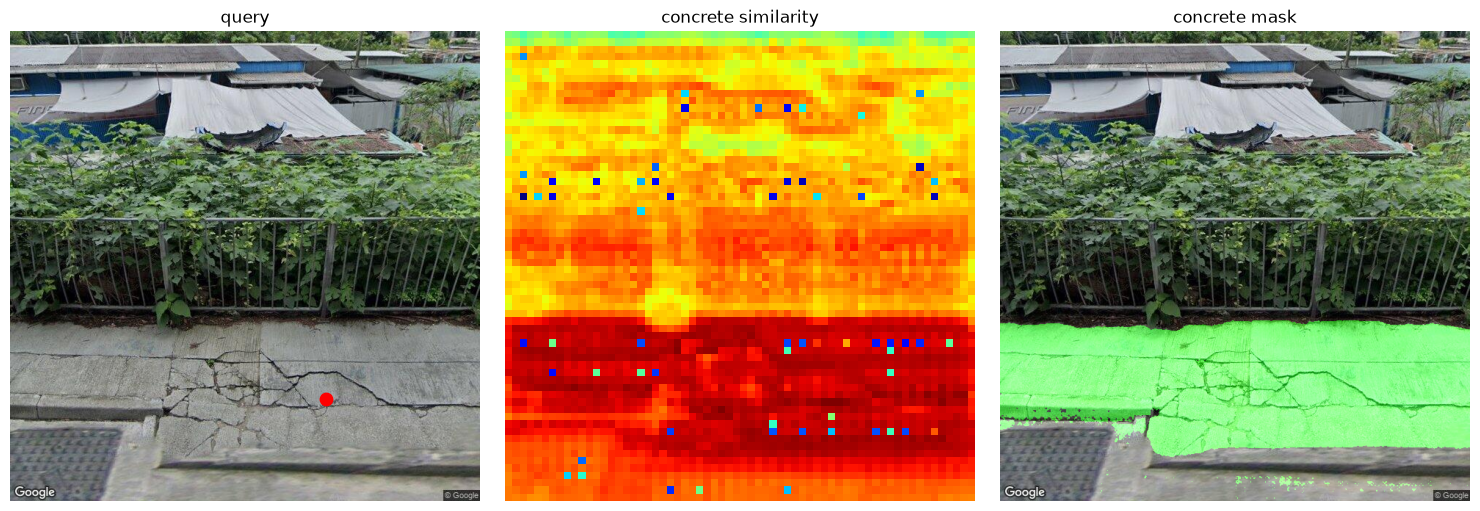

concrete: 101689 px (24.8% of image)


In [178]:
# ---------------------------------------------------------------------------
# 4. Usage
# ---------------------------------------------------------------------------
# DATA_DIR = "sidewalk/support/concrete"

from pathlib import Path

def build_support_dict(support_dir):
    support_dir = Path(support_dir)
    support = {}

    valid_image_extensions = {".png", ".jpg", ".jpeg"}

    for class_dir in support_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name
        pairs = []

        for img_path in sorted(class_dir.iterdir()):
            # Only accept image files: png, jpg, jpeg
            if img_path.suffix.lower() not in valid_image_extensions:
                continue

            # Skip mask files
            if img_path.stem.endswith("_mask"):
                continue

            # Mask is always PNG, regardless of image extension
            mask_path = img_path.with_name(img_path.stem + "_mask.png")

            if mask_path.exists():
                pairs.append((str(img_path), str(mask_path)))
            else:
                print(f"Warning: no mask found for {img_path}")

        support[class_name] = pairs

    return support

support = build_support_dict("sidewalk/support")

# support = {
#     "concrete": [
#         ("22.50302958565_114.0861339521216_left.png",  "22.50302958565_114.0861339521216_left_mask.png"),
#         ("22.50302958565_114.0861339521216_right.png", "22.50302958565_114.0861339521216_right_mask.png"),
#         ("22.337331978361_114.1761833844959_right.jpg", "22.337331978361_114.1761833844959_right_mask.png"),
#     ],
# }

# prepend the directory to every path
# support = {
#     cls: [(os.path.join(DATA_DIR, ip), os.path.join(DATA_DIR, mp)) for ip, mp in pairs]
#     for cls, pairs in support.items()
# }

prototypes = build_prototypes(support, k_per_class=1)
#
# query = load_image("sidewalk/support/concrete/22.22628890164956_114.2002115282643_left.png")
query = load_image("sidewalk/test/22.43735492635766_114.016669824393_left.png")
results = few_shot_segment(query, prototypes)

for ptype, r in results.items():
    mask, sim_map, pt = r["mask"], r["sim_map"], r["point"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(query);                     ax[0].set_title("query")
    ax[0].scatter(*pt, c="red", s=80)
    ax[1].imshow(sim_map, cmap="jet");       ax[1].set_title(f"{ptype} similarity")
    ax[2].imshow(overlay_mask(query, mask)); ax[2].set_title(f"{ptype} mask")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    print(f"{ptype}: {mask.sum()} px ({100*mask.mean():.1f}% of image)")

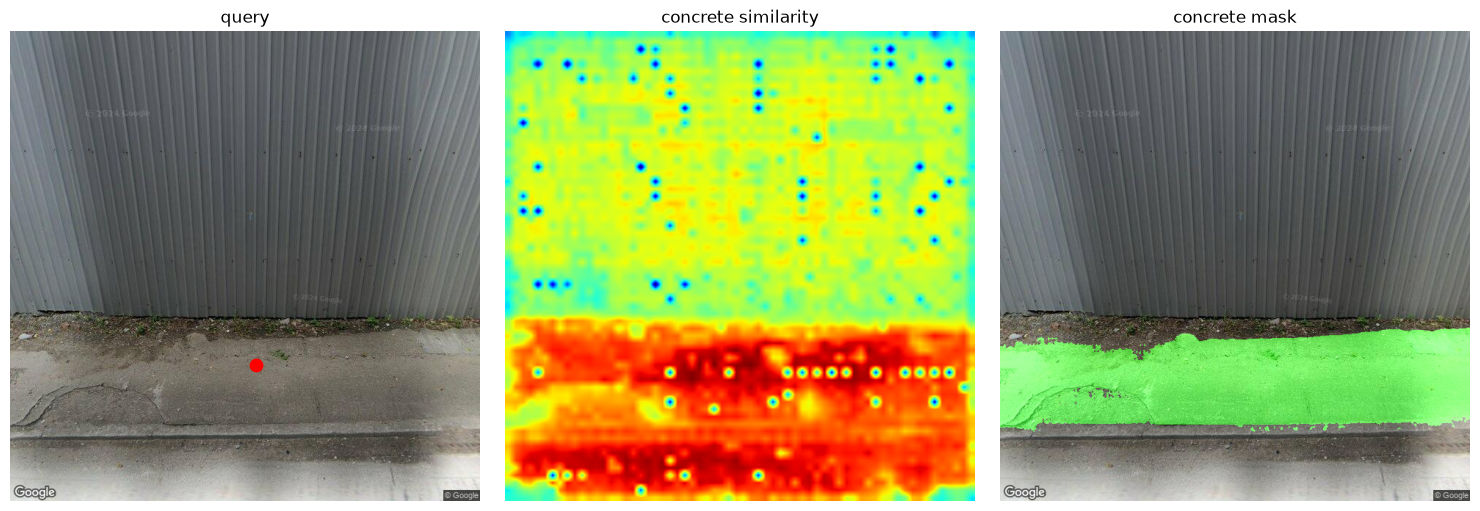

concrete: 74371 px (18.2% of image)


In [42]:
import matplotlib.pyplot as plt

def overlay_mask(image_np, mask, color=(0, 255, 0), alpha=0.5):
    """Blend a binary mask onto an RGB image for visualization."""
    out = image_np.copy()
    colored = np.zeros_like(out)
    colored[mask.astype(bool)] = color
    return cv2.addWeighted(out, 1.0, colored, alpha, 0)

# --- Run on one query image ---
query = load_image("sidewalk/support/concrete/22.50302958565_114.0861339521216_left.png")
results = few_shot_segment(query, prototypes)

for ptype, r in results.items():
    mask, sim_map, pt = r["mask"], r["sim_map"], r["point"]

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(query);                 ax[0].set_title("query")
    ax[0].scatter(*pt, c="red", s=80)    # the prompt point SAM2 used
    ax[1].imshow(sim_map, cmap="jet");   ax[1].set_title(f"{ptype} similarity")
    ax[2].imshow(overlay_mask(query, mask)); ax[2].set_title(f"{ptype} mask")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

    print(f"{ptype}: {mask.sum()} px ({100*mask.mean():.1f}% of image)")

## IoU Scoring

In [175]:
import numpy as np

def binary_metrics(pred, gt):
    """Compare predicted pavement mask vs ground truth. Both (H, W) array-like."""
    pred = np.asarray(pred).astype(bool)
    gt   = np.asarray(gt).astype(bool)

    # Both empty = perfect agreement (nothing to find, nothing predicted)
    if gt.sum() == 0 and pred.sum() == 0:
        return {"iou": 1.0, "dice": 1.0, "precision": 1.0,
                "recall": 1.0, "pixel_acc": 1.0}

    tp = np.logical_and(pred,  gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()

    eps = 1e-8
    return {
        "iou":       tp / (tp + fp + fn + eps),          # main metric
        "dice":      2 * tp / (2 * tp + fp + fn + eps),   # = F1
        "precision": tp / (tp + fp + eps),                # of predicted pavement, how much was right
        "recall":    tp / (tp + fn + eps),                # of real pavement, how much we caught
        "pixel_acc": (tp + tn) / (tp + tn + fp + fn + eps),
    }

## Load ground truth masks
from pathlib import Path
from PIL import Image

def load_gt_mask(img_path, target_hw):
    """Find <stem>_mask.png next to the image and return a bool (H, W) array."""
    img_path = Path(img_path)
    mask_path = img_path.with_name(img_path.stem + "_mask.png")
    if not mask_path.exists():
        return None  # no ground truth -> skip this image in scoring

    m = np.array(Image.open(mask_path).convert("L")) > 127

    H, W = target_hw
    if m.shape != (H, W):
        mi = Image.fromarray((m.astype(np.uint8) * 255)).resize((W, H), Image.NEAREST)
        m = np.array(mi) > 127
    return m

## Define mask union and clean mask 
def combine_pavement_mask(results, target_hw):
    """Union all class masks from few_shot_segment -> single (H, W) bool mask."""
    H, W = target_hw
    combined = np.zeros((H, W), dtype=bool)

    for cls, r in results.items():
        m = np.asarray(r["mask"]).astype(bool)

        # safety net: SAM2 normally already returns (H, W), but rescale if not
        if m.shape != (H, W):
            mi = Image.fromarray((m.astype(np.uint8) * 255)).resize((W, H), Image.NEAREST)
            m = np.array(mi) > 127

        combined |= m

    return combined

def clean_mask(mask):
    """Keep largest connected component and fill holes. Requires opencv-python."""
    import cv2
    m = (mask.astype(np.uint8)) * 255

    # keep largest connected component
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n > 1:
        largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        m = np.where(labels == largest, 255, 0).astype(np.uint8)

    # fill interior holes
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,
                         cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
    return m > 127

## Evaluate over the test set
import glob, os

def evaluate(test_dir, prototypes, clean=True):
    paths = [p for p in glob.glob(os.path.join(test_dir, "**", "*"), recursive=True)
             if p.lower().endswith((".png", ".jpg", ".jpeg"))
             and not Path(p).stem.endswith("_mask")]

    per_image = {}
    for p in paths:
        image = load_image(p)
        H, W  = image.shape[:2]

        gt = load_gt_mask(p, (H, W))
        if gt is None:
            print(f"skip (no mask): {os.path.basename(p)}")
            continue

        results = few_shot_segment(image, prototypes)
        pred    = combine_pavement_mask(results, (H, W))
        if clean:
            pred = clean_mask(pred)

        m = binary_metrics(pred, gt)
        per_image[p] = m
        print(f"{os.path.basename(p):50s}  IoU={m['iou']:.3f}  "
              f"Dice={m['dice']:.3f}  P={m['precision']:.3f}  R={m['recall']:.3f}")

    if not per_image:
        print("No images with ground-truth masks found.")
        return None

    # Mean over the dataset
    keys = ["iou", "dice", "precision", "recall", "pixel_acc"]
    means = {k: float(np.mean([v[k] for v in per_image.values()])) for k in keys}

    print("\n" + "=" * 60)
    print(f"  Evaluated on {len(per_image)} images")
    print(f"  mean IoU       : {means['iou']:.4f}   <-- headline metric")
    print(f"  mean Dice (F1) : {means['dice']:.4f}")
    print(f"  mean Precision : {means['precision']:.4f}")
    print(f"  mean Recall    : {means['recall']:.4f}")
    print(f"  mean Pixel Acc : {means['pixel_acc']:.4f}")
    print("=" * 60)

    return {"per_image": per_image, "means": means}

In [177]:
# Run evaluation on the test set
scores = evaluate("sidewalk/eval_metrics", prototypes, clean=True)

22.22585902296527_114.2019958098524_left.png        IoU=0.820  Dice=0.901  P=0.978  R=0.835
22.22585902296527_114.2019958098524_right.png       IoU=0.980  Dice=0.990  P=0.988  R=0.991
22.22587746058846_114.2014025921368_left.png        IoU=0.685  Dice=0.813  P=0.726  R=0.923
22.22628890164956_114.2002115282643_left.png        IoU=0.639  Dice=0.780  P=0.727  R=0.842
22.22633235941259_114.2001263549638_left.png        IoU=0.830  Dice=0.907  P=0.845  R=0.979
22.22653699757056_114.1997998118049_right.png       IoU=0.935  Dice=0.966  P=0.941  R=0.994
22.30144409674409_114.2378193990778_right.jpg       IoU=0.287  Dice=0.446  P=0.996  R=0.287
22.4354594570303_114.0150316359369_right.png        IoU=0.761  Dice=0.864  P=0.776  R=0.976
22.4361515641235_114.0196239574928_left.png         IoU=0.887  Dice=0.940  P=0.981  R=0.903
22.4361843952782_114.0119616846419_left.png         IoU=0.865  Dice=0.928  P=0.938  R=0.918
22.4361843952782_114.0119616846419_right.png        IoU=0.523  Dice=0.687  P=0.5

In [126]:
# Run evaluation on the test set
scores = evaluate("sidewalk/eval_metrics", prototypes, clean=True)

22.22585902296527_114.2019958098524_left.png        IoU=0.981  Dice=0.991  P=0.985  R=0.996
22.22585902296527_114.2019958098524_right.png       IoU=0.982  Dice=0.991  P=0.991  R=0.990
22.22587746058846_114.2014025921368_left.png        IoU=0.695  Dice=0.820  P=0.731  R=0.933
22.22628890164956_114.2002115282643_left.png        IoU=0.649  Dice=0.787  P=0.729  R=0.855
22.22633235941259_114.2001263549638_left.png        IoU=0.831  Dice=0.908  P=0.846  R=0.980
22.22653699757056_114.1997998118049_right.png       IoU=0.912  Dice=0.954  P=0.921  R=0.989
22.30144409674409_114.2378193990778_right.jpg       IoU=0.276  Dice=0.433  P=0.996  R=0.277
22.4354594570303_114.0150316359369_right.png        IoU=0.739  Dice=0.850  P=0.814  R=0.889
22.4361515641235_114.0196239574928_left.png         IoU=0.839  Dice=0.913  P=0.928  R=0.898
22.4361843952782_114.0119616846419_left.png         IoU=0.367  Dice=0.537  P=0.372  R=0.962
22.4361843952782_114.0119616846419_right.png        IoU=0.543  Dice=0.704  P=0.5

## Use the model to obtain only sidewalk pavement areas

### Block 1 — Imports & config

In [64]:
import os
import glob
import numpy as np
from PIL import Image

# Where your query images live and where results go
INPUT_DIR  = "sidewalk/test"
OUTPUT_DIR = "sidewalk/pavement_rgb"

# Pixel value used to pad out (remove) everything that is NOT pavement.
# 0 = black. Detection models generally handle black padding fine.
FILL_VALUE = 0

# Image extensions to process
EXTS = (".png", ".jpg", ".jpeg")

os.makedirs(OUTPUT_DIR, exist_ok=True)

### Block 2 — Coerce the model output into a clean binary mask

In [65]:
def combine_pavement_mask(results, target_hw):
    """Union all class masks from few_shot_segment -> single (H, W) bool mask."""
    H, W = target_hw
    combined = np.zeros((H, W), dtype=bool)

    for cls, r in results.items():
        m = np.asarray(r["mask"]).astype(bool)

        # safety net: SAM2 normally already returns (H, W), but rescale if not
        if m.shape != (H, W):
            mi = Image.fromarray((m.astype(np.uint8) * 255)).resize((W, H), Image.NEAREST)
            m = np.array(mi) > 127

        combined |= m

    return combined

### Block 3 — (Optional) clean up the mask

In [66]:
def clean_mask(mask):
    """Keep largest connected component and fill holes. Requires opencv-python."""
    import cv2
    m = (mask.astype(np.uint8)) * 255

    # keep largest connected component
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n > 1:
        largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        m = np.where(labels == largest, 255, 0).astype(np.uint8)

    # fill interior holes
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,
                         cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
    return m > 127

### Block 4 — Apply the mask: keep pavement RGB, pad the rest

In [67]:
def apply_mask_rgb(image, mask, fill_value=FILL_VALUE):
    """Return an RGB image (same HxW) where only `mask` keeps original pixels."""
    image = np.asarray(image)
    if image.ndim == 2:                       # grayscale -> RGB
        image = np.stack([image] * 3, axis=-1)
    image = image[..., :3]                    # drop alpha if present

    mask = mask.astype(bool)
    out = np.full_like(image, fill_value)     # padded background
    out[mask] = image[mask]                   # paste pavement RGB
    return out

### Block 5 — Process a single image end to end

In [68]:
def segment_pavement(img_path, prototypes, clean=True):
    """Run few-shot model on one image -> RGB pavement on a padded background."""
    image = load_image(img_path)                          # your loader (NumPy array)
    H, W = image.shape[:2]

    results = few_shot_segment(image, prototypes)         # {class: {"mask", ...}}
    mask    = combine_pavement_mask(results, (H, W))      # union -> (H, W) bool

    if clean:
        mask = clean_mask(mask)

    pavement_rgb = apply_mask_rgb(image, mask)            # (H, W, 3), background padded
    return pavement_rgb, mask

### Block 6 — Batch over a whole folder

In [69]:
def batch_segment_pavement(input_dir=INPUT_DIR, output_dir=OUTPUT_DIR,
                           prototypes=None, clean=True, save_mask=False):
    assert prototypes is not None, "Pass your built `prototypes`."

    paths = [p for p in glob.glob(os.path.join(input_dir, "**", "*"), recursive=True)
             if p.lower().endswith(EXTS)]
    print(f"Found {len(paths)} images in {input_dir}")

    results = {}
    for i, p in enumerate(paths, 1):
        try:
            pavement_rgb, mask = segment_pavement(p, prototypes, clean=clean)

            stem = os.path.splitext(os.path.basename(p))[0]
            out_rgb = os.path.join(output_dir, f"{stem}_pavement.png")
            Image.fromarray(pavement_rgb).save(out_rgb)

            if save_mask:
                out_m = os.path.join(output_dir, f"{stem}_mask.png")
                Image.fromarray((mask.astype(np.uint8) * 255)).save(out_m)

            results[p] = out_rgb
            print(f"[{i}/{len(paths)}] ✓ {os.path.basename(p)} "
                  f"(pavement covers {mask.mean()*100:.1f}% of frame)")
        except Exception as e:
            print(f"[{i}/{len(paths)}] ✗ {os.path.basename(p)} -> {e}")

    print(f"\nDone. {len(results)} images written to {output_dir}")
    return results

### Block 7 — Run it

In [ ]:
results = batch_segment_pavement(
    input_dir="sidewalk/test",
    output_dir="sidewalk/pavement_rgb",
    prototypes=prototypes,   
    clean=True,              # set False if you don't have opencv
    save_mask=False,         
)

Found 3 images in sidewalk/test
[1/3] ✓ 22.43735492635766_114.016669824393_left.png (pavement covers 24.8% of frame)
[2/3] ✓ 22.43745812725892_114.067148676439_left.png (pavement covers 17.1% of frame)
[3/3] ✓ 22.43758168455717_114.0668922641029_right.png (pavement covers 17.8% of frame)

Done. 3 images written to sidewalk/pavement_rgb
